# Analise exploratoria dos dados telefonicos de Lavras

Este notebook documenta e expande a exploracao inicial do projeto. A base principal, `Lavras.parquet`, esta agregada por emissor residente em Lavras: cada linha contem um usuario emissor, totais gerais e listas com informacoes dos receptores correspondentes.

A base `residencias.csv` e muito maior e contem informacoes de residencia e quintis. Por isso, a exploracao dela e feita por amostra ou leitura em partes, evitando carregar quase 1 GB de dados em toda execucao.

## Perguntas iniciais

- Quantos emissores existem na amostra de Lavras?
- As listas internas do parquet sao consistentes com `unique_receivers` e `total_calls_make`?
- Como se distribuem chamadas, receptores unicos, distancias e duracoes?
- Ha usuarios que concentram grande parte do volume de chamadas?
- A comunicacao e majoritariamente local ou ha muitos vinculos de longa distancia?
- Como preparar uma tabela de arestas emissor-receptor para analises posteriores?
- Como agregar a base grande de residencias por cidade e quintis sem carregar tudo em memoria?

In [62]:
from pathlib import Path
import sys

# Evita importar extensoes opcionais incompat?veis com NumPy 2.x neste ambiente.
sys.modules['numexpr'] = None
sys.modules['bottleneck'] = None

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('.')
LAVRAS_PATH = DATA_DIR / 'Lavras.parquet'
RESIDENCIAS_PATH = DATA_DIR / 'residencias.csv'

LAVRAS_PATH.exists(), RESIDENCIAS_PATH.exists()

(True, True)

## Dicionario inicial de dados

| Coluna | Descricao inferida |
|---|---|
| `city_residences` | Cidade de residencia do emissor. Neste recorte, deve ser Lavras. |
| `id_emisor` | Identificador anonimizado do usuario emissor. |
| `total_calls_make` | Total de chamadas feitas pelo emissor. |
| `unique_receivers` | Quantidade de receptores distintos chamados pelo emissor. |
| `IDs_receivers_corr` | Lista de identificadores anonimizados dos receptores. |
| `q_calls_corr` | Lista com quantidade de chamadas para cada receptor correspondente. |
| `residence_distance_km_corr` | Lista com distancia residencial, em km, entre emissor e receptor correspondente. |
| `calls_duration_total_corr` | Lista com duracao total das chamadas para cada receptor correspondente. |

As colunas com sufixo `_corr` precisam ter o mesmo comprimento linha a linha, pois representam atributos de uma mesma aresta emissor-receptor.

## Carregamento e estrutura do parquet

In [63]:
parquet_file = pq.ParquetFile(LAVRAS_PATH)
print(parquet_file.schema)
print(f'Linhas: {parquet_file.metadata.num_rows:,}')
print(f'Grupos de linhas: {parquet_file.metadata.num_row_groups}')

required group field_id=-1 schema {
  optional binary field_id=-1 city_residences (String);
  optional binary field_id=-1 id_emisor (String);
  optional int64 field_id=-1 total_calls_make;
  optional int64 field_id=-1 unique_receivers;
  optional group field_id=-1 IDs_receivers_corr (List) {
    repeated group field_id=-1 list {
      optional binary field_id=-1 element (String);
    }
  }
  optional group field_id=-1 q_calls_corr (List) {
    repeated group field_id=-1 list {
      optional int64 field_id=-1 element;
    }
  }
  optional group field_id=-1 residence_distance_km_corr (List) {
    repeated group field_id=-1 list {
      optional double field_id=-1 element;
    }
  }
  optional group field_id=-1 calls_duration_total_corr (List) {
    repeated group field_id=-1 list {
      optional double field_id=-1 element;
    }
  }
}

Linhas: 2,968
Grupos de linhas: 1


In [64]:
lavras = parquet_file.read().to_pandas()
lavras.head()

,city_residences,id_emisor,total_calls_make,unique_receivers,IDs_receivers_corr,q_calls_corr,residence_distance_km_corr,calls_duration_total_corr
0,Lavras,6A25BB13E0EB57AF0BC1B12E09066090,3,1,[09733364070D428DB7DB059EB964AEEA],[3],[1.6244811412788938],[8.469999999999999]
1,Lavras,A1F433373241547B7E7D0E4E63A8574F,27,1,[EAFB8A6F8D9AD7E91529F6EF7F15BF2B],[27],[1.6244811412788938],[19.590000000000003]
2,Lavras,C0EE955E574B587D037F1DC493ADDEC4,1,1,[54AAE028CCC31C4B800CB1E7E9799253],[1],[3.0086606658789745],[1.43]
3,Lavras,66406B8907461FBB978468BE0D0E22F1,3,1,[033183C2EE18E03EFDF1083D53EE92B5],[3],[1.5927049003955993],[29.29]
4,Lavras,EB4EF78A3B0BAAD118885F2B93881B5F,22,2,"[3F895921B209C4161B721382802BD3BC, 3DB84B3C732D58C6DE17A63C3C5618C0]","[21, 1]","[0.0, 0.0]","[18.19, 0.97]"


## Qualidade e consistencia

A validacao abaixo verifica nulos, duplicatas de emissor e consistencia entre a quantidade declarada de receptores, os comprimentos das listas e o total de chamadas. Essa etapa e importante porque as analises de rede dependem da correta correspondencia entre as listas.

In [65]:
resumo_colunas = pd.DataFrame({
    'tipo': lavras.dtypes.astype(str),
    'nulos': lavras.isna().sum(),
    'pct_nulos': lavras.isna().mean(),
    'n_unicos': [lavras[col].astype(str).nunique() for col in lavras.columns],
})
resumo_colunas

,tipo,nulos,pct_nulos,n_unicos
city_residences,str,0,0.0,1
id_emisor,str,0,0.0,2968
total_calls_make,int64,0,0.0,234
unique_receivers,int64,0,0.0,36
IDs_receivers_corr,object,0,0.0,2911
q_calls_corr,object,0,0.0,1927
residence_distance_km_corr,object,0,0.0,1488
calls_duration_total_corr,object,0,0.0,2775


In [66]:
list_cols = ['IDs_receivers_corr', 'q_calls_corr', 'residence_distance_km_corr', 'calls_duration_total_corr']

for col in list_cols:
    lavras[f'n_{col}'] = lavras[col].apply(len)

lavras['soma_q_calls_corr'] = lavras['q_calls_corr'].apply(sum)

checks = pd.DataFrame({
    'linhas': [len(lavras)],
    'emissores_unicos': [lavras['id_emisor'].nunique()],
    'emissores_duplicados': [lavras['id_emisor'].duplicated().sum()],
    'cidades': [', '.join(sorted(lavras['city_residences'].unique()))],
    'unique_receivers_confere': [(lavras['unique_receivers'] == lavras['n_IDs_receivers_corr']).all()],
    'listas_mesmo_tamanho': [(lavras[[f'n_{c}' for c in list_cols]].nunique(axis=1) == 1).all()],
    'total_calls_confere': [(lavras['total_calls_make'] == lavras['soma_q_calls_corr']).all()],
})
checks

,linhas,emissores_unicos,emissores_duplicados,cidades,unique_receivers_confere,listas_mesmo_tamanho,total_calls_confere
0,2968,2968,0,Lavras,True,True,True


In [67]:
inconsistencias = lavras.loc[
    (lavras['unique_receivers'] != lavras['n_IDs_receivers_corr']) |
    (lavras[[f'n_{c}' for c in list_cols]].nunique(axis=1) != 1) |
    (lavras['total_calls_make'] != lavras['soma_q_calls_corr']),
    ['id_emisor', 'total_calls_make', 'soma_q_calls_corr', 'unique_receivers'] + [f'n_{c}' for c in list_cols]
]

inconsistencias.head()

,id_emisor,total_calls_make,soma_q_calls_corr,unique_receivers,n_IDs_receivers_corr,n_q_calls_corr,n_residence_distance_km_corr,n_calls_duration_total_corr


## Estatisticas descritivas dos emissores

Aqui olhamos para o comportamento por emissor: volume total de chamadas e diversidade de contatos. Como dados telefonicos costumam ter cauda longa, a mediana e os percentis sao mais informativos que a media isolada.

In [68]:
emissor_cols = ['total_calls_make', 'unique_receivers']
lavras[emissor_cols].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
total_calls_make,2968.0,39.405323,53.080334,1.0,1.0,1.0,6.0,20.0,51.0,101.0,144.3,243.99,581.0
unique_receivers,2968.0,4.188679,4.032324,1.0,1.0,1.0,2.0,3.0,5.0,8.0,11.0,20.00,40.0


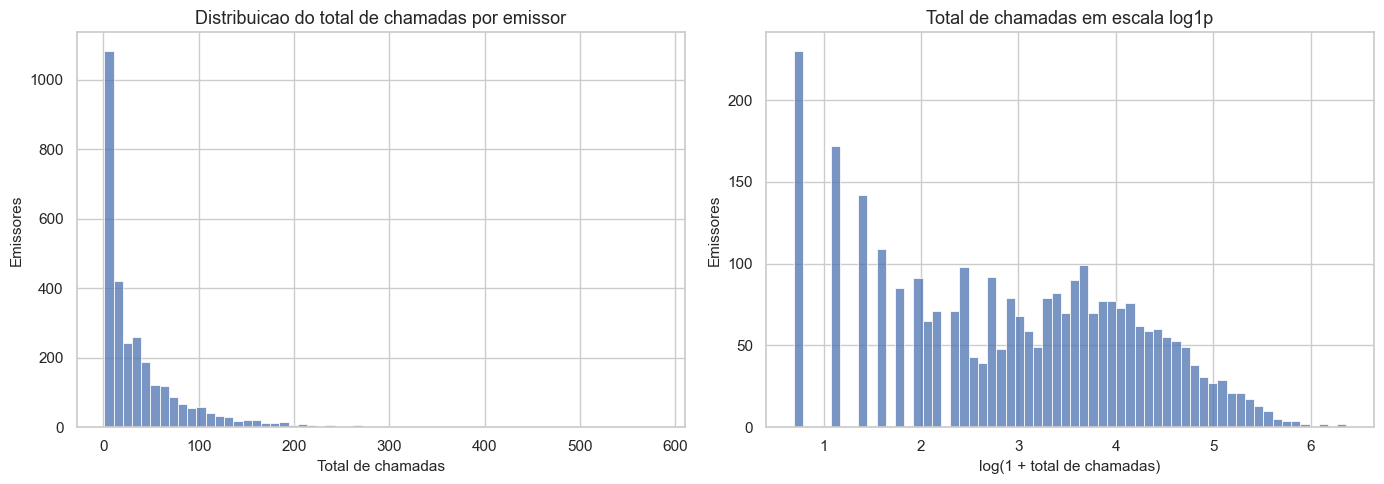

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=lavras, x='total_calls_make', bins=60, ax=axes[0])
axes[0].set_title('Distribuicao do total de chamadas por emissor')
axes[0].set_xlabel('Total de chamadas')
axes[0].set_ylabel('Emissores')

sns.histplot(x=np.log1p(lavras['total_calls_make']), bins=60, ax=axes[1])
axes[1].set_title('Total de chamadas em escala log1p')
axes[1].set_xlabel('log(1 + total de chamadas)')
axes[1].set_ylabel('Emissores')

plt.tight_layout()
plt.show()

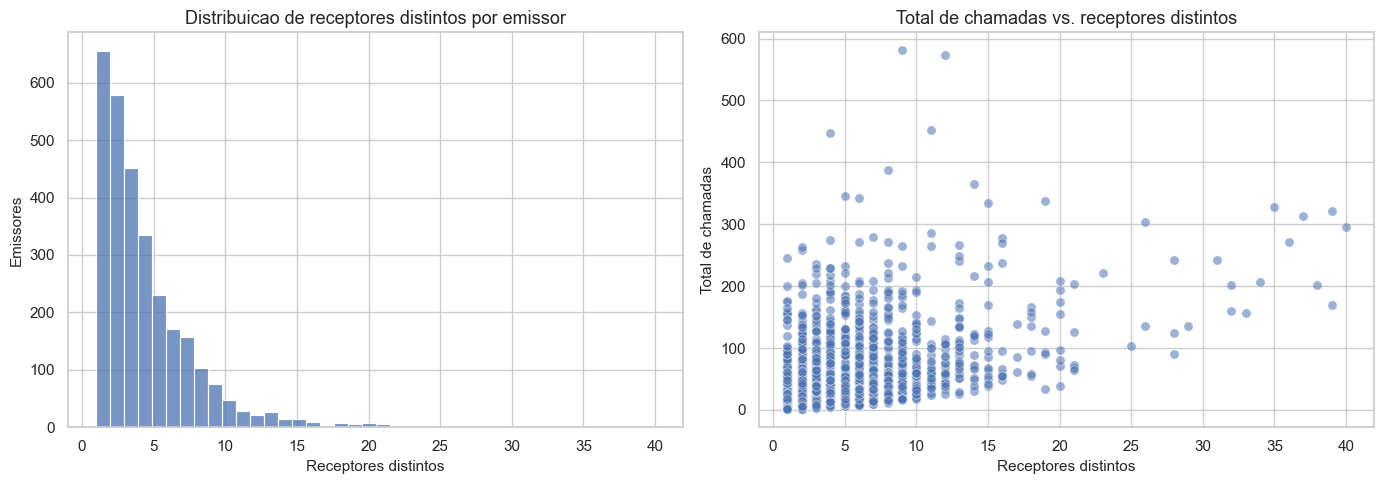

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=lavras, x='unique_receivers', bins=40, ax=axes[0])
axes[0].set_title('Distribuicao de receptores distintos por emissor')
axes[0].set_xlabel('Receptores distintos')
axes[0].set_ylabel('Emissores')

sns.scatterplot(data=lavras, x='unique_receivers', y='total_calls_make', alpha=0.55, s=45, ax=axes[1])
axes[1].set_title('Total de chamadas vs. receptores distintos')
axes[1].set_xlabel('Receptores distintos')
axes[1].set_ylabel('Total de chamadas')

plt.tight_layout()
plt.show()

## Pareto de volume de chamadas

Esta analise mostra quanto do volume total de chamadas e explicado pelos emissores mais ativos. Se a curva acumular rapidamente, poucos usuarios concentram grande parte das chamadas.

In [71]:
pareto = lavras[['id_emisor', 'total_calls_make', 'unique_receivers']].sort_values('total_calls_make', ascending=False).reset_index(drop=True)
pareto['rank'] = np.arange(1, len(pareto) + 1)
pareto['pct_emissores'] = pareto['rank'] / len(pareto)
pareto['pct_chamadas_acum'] = pareto['total_calls_make'].cumsum() / pareto['total_calls_make'].sum()
pareto.head(15)

,id_emisor,total_calls_make,unique_receivers,rank,pct_emissores,pct_chamadas_acum
0,645254314639EDACA0DFCD37DCF6A2DD,581,9,1,0.000337,0.004968
1,8DE7ECCB2BD455F7883092DD0567D43B,574,12,2,0.000674,0.009876
2,1A1C2B664417B00DEF20104017E778BD,453,11,3,0.001011,0.013749
3,36FE36ED18B50C18B29D1A16275E64CF,447,4,4,0.001348,0.017571
4,47A1310E83C6871424E6106584B5724A,387,8,5,0.001685,0.020880
5,E70490E25BFF4AEA2C8E966E7F72D4BA,365,14,6,0.002022,0.024001
6,A23B55E0005C0BB7BEE6FC96944140C1,345,5,7,0.002358,0.026951
7,127BC2BA57366C0E58F1DC75427ED796,343,6,8,0.002695,0.029883
8,F0B60CA06AA2036C6B519470EFC25D2A,338,19,9,0.003032,0.032773
9,E7AFDDF4A191642EB2733A355EAC57AB,334,15,10,0.003369,0.035629


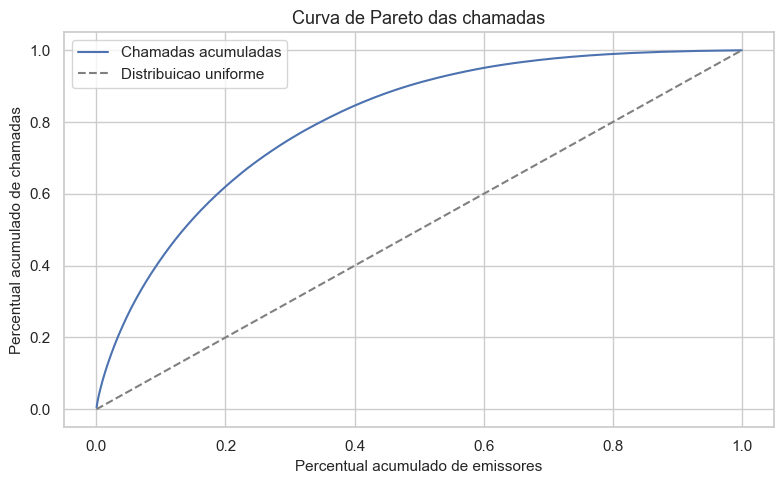

Top 1% dos emissores: 8.3% das chamadas
Top 5% dos emissores: 26.9% das chamadas
Top 10% dos emissores: 41.9% das chamadas
Top 20% dos emissores: 62.0% das chamadas


In [72]:
plt.figure(figsize=(8, 5))
plt.plot(pareto['pct_emissores'], pareto['pct_chamadas_acum'], label='Chamadas acumuladas')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Distribuicao uniforme')
plt.title('Curva de Pareto das chamadas')
plt.xlabel('Percentual acumulado de emissores')
plt.ylabel('Percentual acumulado de chamadas')
plt.legend()
plt.tight_layout()
plt.show()

for corte in [0.01, 0.05, 0.10, 0.20]:
    n = max(1, int(np.ceil(corte * len(pareto))))
    pct = pareto.loc[:n-1, 'total_calls_make'].sum() / pareto['total_calls_make'].sum()
    print(f'Top {corte:.0%} dos emissores: {pct:.1%} das chamadas')

## Transformacao para arestas emissor-receptor

As listas do parquet sao expandidas para uma linha por par emissor-receptor. Essa estrutura facilita analises de distancia, duracao, intensidade e rede.

In [73]:
edges_records = []

for row in lavras.itertuples(index=False):
    for receiver, q_calls, distance_km, duration_total in zip(
        row.IDs_receivers_corr,
        row.q_calls_corr,
        row.residence_distance_km_corr,
        row.calls_duration_total_corr,
    ):
        edges_records.append({
            'city_residences': row.city_residences,
            'id_emisor': row.id_emisor,
            'id_receiver': receiver,
            'q_calls': q_calls,
            'residence_distance_km': distance_km,
            'calls_duration_total': duration_total,
        })

edges = pd.DataFrame(edges_records)
edges['avg_duration_per_call'] = edges['calls_duration_total'] / edges['q_calls'].replace(0, np.nan)
edges.head()

,city_residences,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call
0,Lavras,6A25BB13E0EB57AF0BC1B12E09066090,09733364070D428DB7DB059EB964AEEA,3,1.624481,8.47,2.823333
1,Lavras,A1F433373241547B7E7D0E4E63A8574F,EAFB8A6F8D9AD7E91529F6EF7F15BF2B,27,1.624481,19.59,0.725556
2,Lavras,C0EE955E574B587D037F1DC493ADDEC4,54AAE028CCC31C4B800CB1E7E9799253,1,3.008661,1.43,1.430000
3,Lavras,66406B8907461FBB978468BE0D0E22F1,033183C2EE18E03EFDF1083D53EE92B5,3,1.592705,29.29,9.763333
4,Lavras,EB4EF78A3B0BAAD118885F2B93881B5F,3F895921B209C4161B721382802BD3BC,21,0.000000,18.19,0.866190


In [74]:
pd.DataFrame({
    'arestas': [len(edges)],
    'emissores': [edges['id_emisor'].nunique()],
    'receptores': [edges['id_receiver'].nunique()],
    'pares_duplicados': [edges.duplicated(['id_emisor', 'id_receiver']).sum()],
    'chamadas_total_edges': [edges['q_calls'].sum()],
    'chamadas_total_emissores': [lavras['total_calls_make'].sum()],
})

,arestas,emissores,receptores,pares_duplicados,chamadas_total_edges,chamadas_total_emissores
0,12432,2968,2926,0,116955,116955


## Distancia, duracao e intensidade das arestas

A distancia residencial entre emissor e receptor permite observar se a comunicacao e majoritariamente local ou se ha muitos vinculos de longa distancia. A duracao media por chamada ajuda a diferenciar contatos frequentes e curtos de contatos menos frequentes e longos.

In [75]:
edges[['q_calls', 'residence_distance_km', 'calls_duration_total', 'avg_duration_per_call']].describe(percentiles=[.01, .05, .25, .5, .75, .9, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
q_calls,12432.0,9.407577,21.796157,1.0,1.00,1.00,1.00,2.000000,7.000000,22.00000,42.000000,106.000000,528.000000
residence_distance_km,12432.0,1.423080,1.435048,0.0,0.00,0.00,0.00,1.592705,2.203147,3.18721,4.675603,4.736802,12.231602
calls_duration_total,12432.0,13.397286,44.574479,0.0,0.07,0.16,0.82,2.350000,8.032500,26.40700,57.542500,218.253900,1392.430000
avg_duration_per_call,12432.0,1.256401,1.721265,0.0,0.07,0.13,0.45,0.800000,1.420000,2.65000,3.824083,7.562854,42.380000


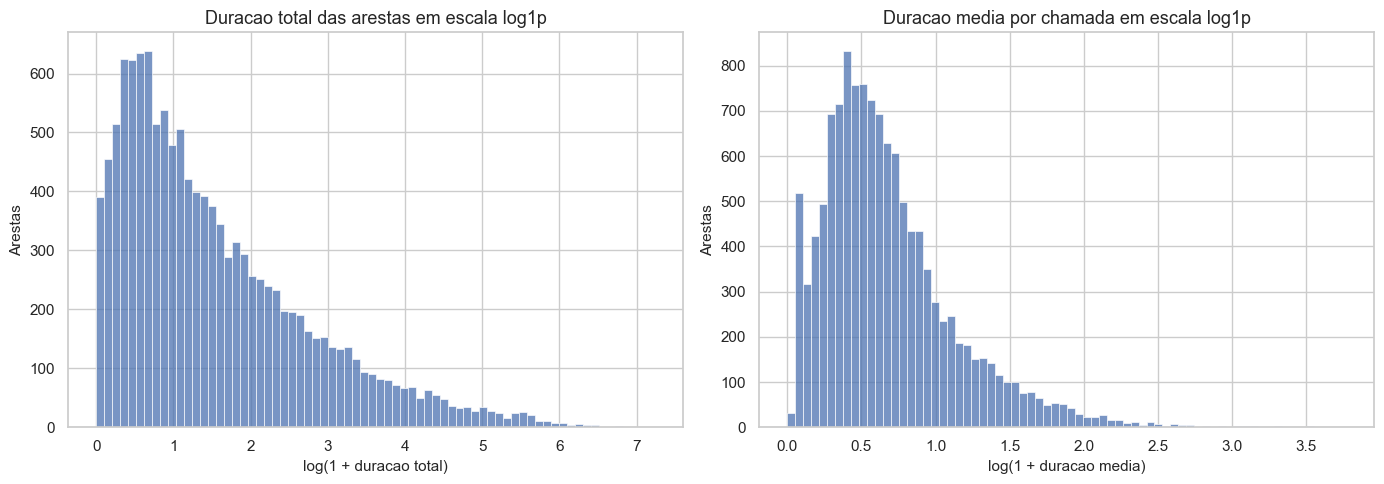

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(x=np.log1p(edges['calls_duration_total']), bins=70, ax=axes[0])
axes[0].set_title('Duracao total das arestas em escala log1p')
axes[0].set_xlabel('log(1 + duracao total)')
axes[0].set_ylabel('Arestas')

sns.histplot(x=np.log1p(edges['avg_duration_per_call']), bins=70, ax=axes[1])
axes[1].set_title('Duracao media por chamada em escala log1p')
axes[1].set_xlabel('log(1 + duracao media)')
axes[1].set_ylabel('Arestas')

plt.tight_layout()
plt.show()

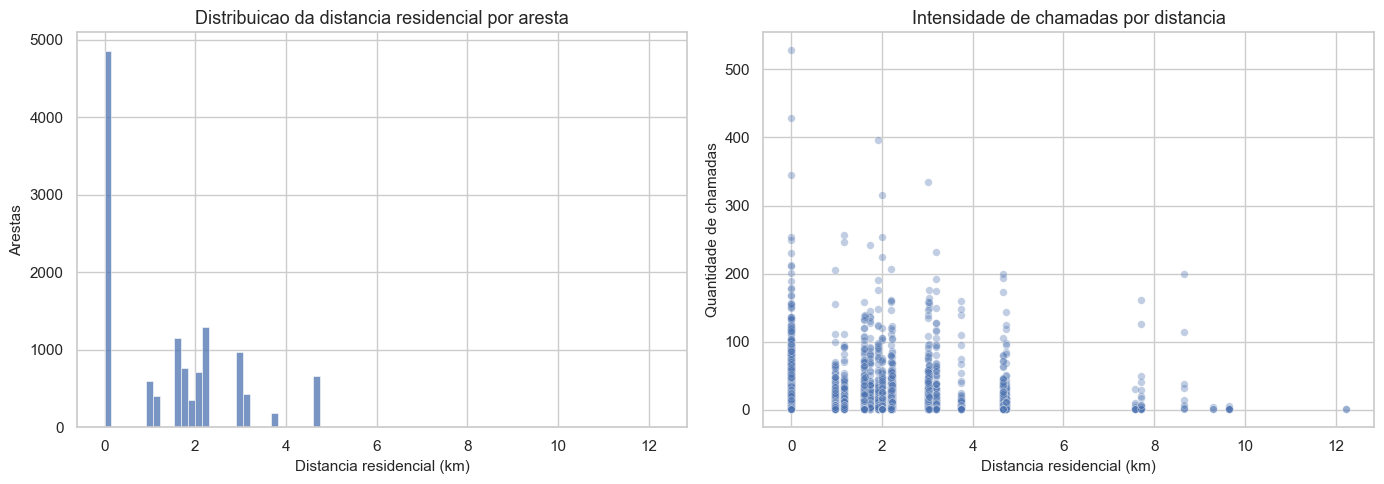

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=edges, x='residence_distance_km', bins=80, ax=axes[0])
axes[0].set_title('Distribuicao da distancia residencial por aresta')
axes[0].set_xlabel('Distancia residencial (km)')
axes[0].set_ylabel('Arestas')

sns.scatterplot(data=edges, x='residence_distance_km', y='q_calls', alpha=0.35, s=30, ax=axes[1])
axes[1].set_title('Intensidade de chamadas por distancia')
axes[1].set_xlabel('Distancia residencial (km)')
axes[1].set_ylabel('Quantidade de chamadas')

plt.tight_layout()
plt.show()

In [78]:
bins = [-np.inf, 1, 5, 10, 25, 50, 100, 250, 500, np.inf]
labels = ['<=1', '1-5', '5-10', '10-25', '25-50', '50-100', '100-250', '250-500', '>500']
edges['faixa_distancia_km'] = pd.cut(edges['residence_distance_km'], bins=bins, labels=labels)

dist_summary = edges.groupby('faixa_distancia_km', observed=False).agg(
    arestas=('id_receiver', 'size'),
    chamadas=('q_calls', 'sum'),
    duracao_total=('calls_duration_total', 'sum'),
    chamadas_mediana=('q_calls', 'median'),
).reset_index()
dist_summary['pct_arestas'] = dist_summary['arestas'] / dist_summary['arestas'].sum()
dist_summary['pct_chamadas'] = dist_summary['chamadas'] / dist_summary['chamadas'].sum()
dist_summary

,faixa_distancia_km,arestas,chamadas,duracao_total,chamadas_mediana,pct_arestas,pct_chamadas
0,<=1,5457,58729,70068.55,3.0,0.438948,0.502150
1,1-5,6926,57247,94641.74,2.0,0.557111,0.489479
2,5-10,47,976,1844.37,3.0,0.003781,0.008345
3,10-25,2,3,0.40,1.5,0.000161,0.000026
4,25-50,0,0,0.00,NaN,0.000000,0.000000
5,50-100,0,0,0.00,NaN,0.000000,0.000000
6,100-250,0,0,0.00,NaN,0.000000,0.000000
7,250-500,0,0,0.00,NaN,0.000000,0.000000
8,>500,0,0,0.00,NaN,0.000000,0.000000


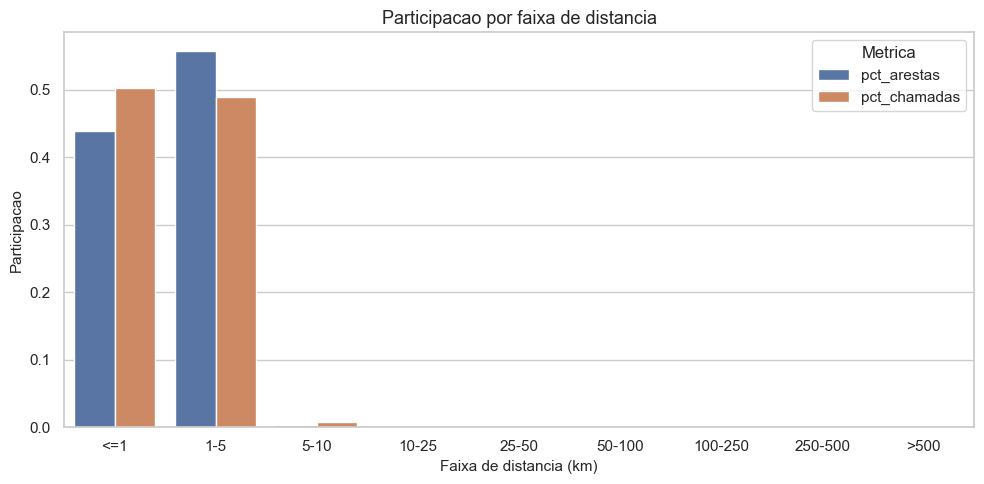

In [79]:
dist_plot = dist_summary.melt(
    id_vars='faixa_distancia_km',
    value_vars=['pct_arestas', 'pct_chamadas'],
    var_name='metrica',
    value_name='participacao',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=dist_plot, x='faixa_distancia_km', y='participacao', hue='metrica')
plt.title('Participacao por faixa de distancia')
plt.xlabel('Faixa de distancia (km)')
plt.ylabel('Participacao')
plt.legend(title='Metrica')
plt.tight_layout()
plt.show()

## Cauda da distribuicao de chamadas por aresta

A CCDF mostra a probabilidade de uma aresta ter pelo menos certo numero de chamadas. Em escala log-log, uma cauda longa aparece como queda lenta, indicando poucos pares com volume muito alto.

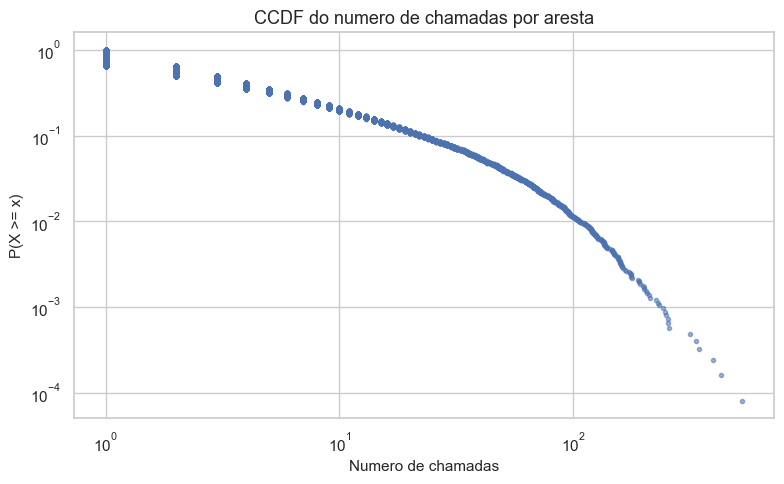

In [80]:
x = np.sort(edges['q_calls'].to_numpy())
y = 1.0 - np.arange(len(x)) / len(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='.', linestyle='none', alpha=0.55)
plt.xscale('log')
plt.yscale('log')
plt.title('CCDF do numero de chamadas por aresta')
plt.xlabel('Numero de chamadas')
plt.ylabel('P(X >= x)')
plt.tight_layout()
plt.show()

## Concentracao de contatos por emissor

A proporcao de chamadas para o principal receptor indica dependencia de um contato dominante. Valores proximos de 1 sugerem que quase todas as chamadas do emissor foram para uma unica pessoa.

In [81]:
concentracao = edges.groupby('id_emisor').agg(
    chamadas_total=('q_calls', 'sum'),
    receptores=('id_receiver', 'nunique'),
    maior_volume_receptor=('q_calls', 'max'),
    distancia_media_ponderada=('residence_distance_km', lambda s: np.average(s, weights=edges.loc[s.index, 'q_calls'])),
).reset_index()
concentracao['share_top_receptor'] = concentracao['maior_volume_receptor'] / concentracao['chamadas_total']
concentracao.sort_values(['share_top_receptor', 'chamadas_total'], ascending=[False, False]).head(10)

,id_emisor,chamadas_total,receptores,maior_volume_receptor,distancia_media_ponderada,share_top_receptor
1925,A6AE1DF871C578027801417C91B59ADA,246,1,246,1.160592,1.0
1702,952B1011CF6323AD86BD8063516BF73E,201,1,201,0.000000,1.0
2201,BE5EA69D03B99BAFC8E7B043D8594450,176,1,176,1.909331,1.0
2568,DE134714040F84618425F7C55D4EFF9D,175,1,175,3.187210,1.0
2630,E37415FECDF84BBB69B65016768829F8,164,1,164,3.038583,1.0
418,2277587CC10AA4EA7B98FC90A8E4F380,158,1,158,1.592705,1.0
2488,D820BFA572F5CDE6019210745CF45246,156,1,156,0.000000,1.0
2926,FC557420B3327899B0B8A0868D138A06,155,1,155,3.038583,1.0
1,0013DE3AD6D78AA642B81409E429539B,147,1,147,2.203147,1.0
2154,B9E8AF866E3138705C21E38EF8906AE7,146,1,146,1.737095,1.0


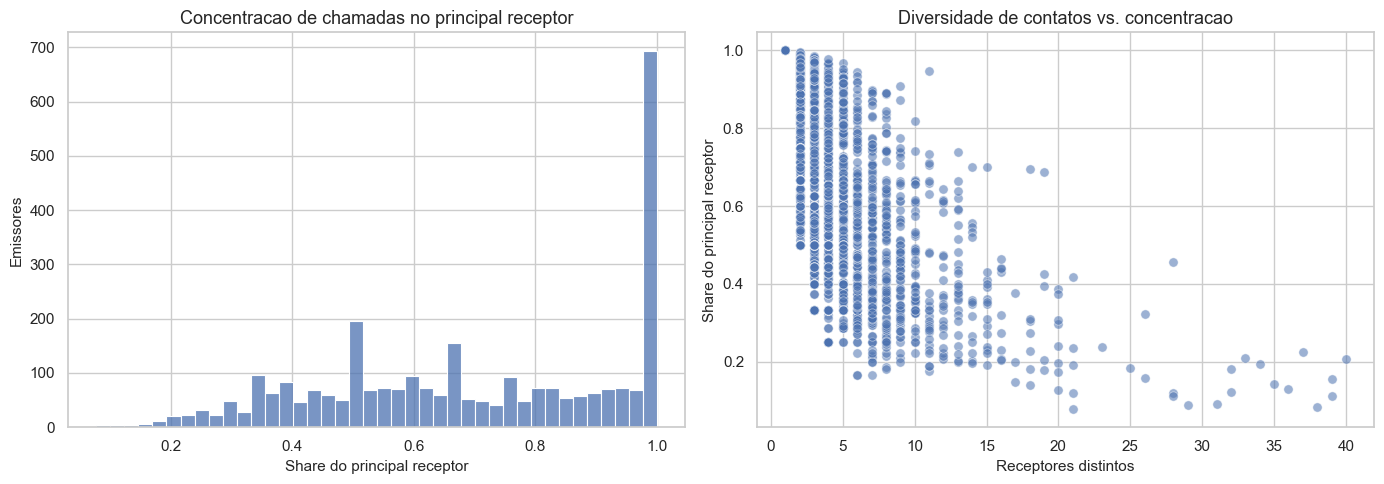

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=concentracao, x='share_top_receptor', bins=40, ax=axes[0])
axes[0].set_title('Concentracao de chamadas no principal receptor')
axes[0].set_xlabel('Share do principal receptor')
axes[0].set_ylabel('Emissores')

sns.scatterplot(data=concentracao, x='receptores', y='share_top_receptor', alpha=0.55, s=45, ax=axes[1])
axes[1].set_title('Diversidade de contatos vs. concentracao')
axes[1].set_xlabel('Receptores distintos')
axes[1].set_ylabel('Share do principal receptor')

plt.tight_layout()
plt.show()

## Amostra de `residencias.csv`

A base de residencias e grande. A celula abaixo le apenas as primeiras 200 mil linhas para uma visao rapida. Para estimativas mais estaveis, aumente `nrows` ou use leitura por chunks agregando contagens.

In [83]:
residencias_sample = pd.read_csv(
    RESIDENCIAS_PATH,
    nrows=200_000,
    usecols=['ID', 'residence_city', 'residence_quintile_state', 'residence_quintile_nation'],
)

residencias_sample.head()

,ID,residence_city,residence_quintile_state,residence_quintile_nation
0,0A7BF148110B6D5AE29939017AEB843A,São Paulo,q1,q1
1,0FBC0A930414D2ED92B6F4B8661BB997,São Paulo,q1,q1
2,0BA404BCA3069A8C9FA6ABE70225A1C8,São Paulo,q1,q1
3,133947C1230823B09FA68416DED5E090,São Paulo,q1,q1
4,0FADED95A81CAC14BD136CAAF597E425,São Paulo,q1,q1


In [84]:
cidade_top = residencias_sample['residence_city'].value_counts().head(15).reset_index()
cidade_top.columns = ['cidade', 'usuarios']
cidade_top

,cidade,usuarios
0,São Paulo,82764
1,Fortaleza,18074
2,Recife,15992
3,Belo Horizonte,9821
4,Rio de Janeiro,9799
5,Porto Alegre,6032
6,São Luís,4835
7,Salvador,4195
8,Belém,4022
9,Ceilândia,3795


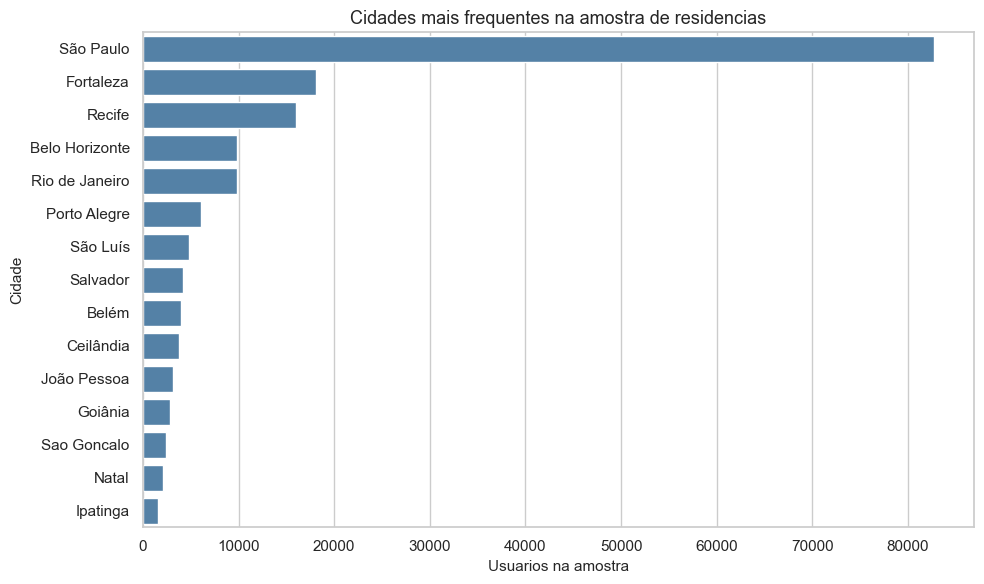

,quintil_estado,quintil_nacional
q1,17889,12725
q2,29870,26372
q3,36495,36434
q4,50901,57162
q5,64845,67307


In [85]:
plt.figure(figsize=(10, 6))
sns.barplot(data=cidade_top, x='usuarios', y='cidade', color='steelblue')
plt.title('Cidades mais frequentes na amostra de residencias')
plt.xlabel('Usuarios na amostra')
plt.ylabel('Cidade')
plt.tight_layout()
plt.show()

quintis = pd.concat([
    residencias_sample['residence_quintile_state'].value_counts().sort_index().rename('quintil_estado'),
    residencias_sample['residence_quintile_nation'].value_counts().sort_index().rename('quintil_nacional'),
], axis=1).fillna(0).astype(int)
quintis

## Cruzamento com residencias de Lavras

Os IDs de interesse combinam os emissores do parquet e os receptores presentes nas arestas. Como o foco atual e Lavras, o cruzamento abaixo busca em `residencias.csv` apenas registros com `residence_city == 'Lavras'` e cujo `ID` aparece nos dados de chamadas.

In [86]:
ids_emissores = set(lavras['id_emisor'])
ids_receptores = set(edges['id_receiver'])
ids_interesse = ids_emissores | ids_receptores

pd.DataFrame({
    'ids_emissores': [len(ids_emissores)],
    'ids_receptores': [len(ids_receptores)],
    'ids_interesse_total': [len(ids_interesse)],
})

,ids_emissores,ids_receptores,ids_interesse_total
0,2968,2926,3112


In [87]:
RESULTADOS_DIR = DATA_DIR / 'resultados_lavras'
RESULTADOS_DIR.mkdir(exist_ok=True)

COLS_RESIDENCIAS = ['ID', 'residence_city', 'residence_quintile_state', 'residence_quintile_nation']

def filtrar_residencias_lavras_por_ids(path, ids, chunksize=500_000):
    partes = []
    ids = set(ids)
    total_linhas = 0
    residentes_lavras = 0

    for chunk in pd.read_csv(path, usecols=COLS_RESIDENCIAS, chunksize=chunksize):
        total_linhas += len(chunk)
        cidade_lavras = chunk['residence_city'].astype(str).str.strip().str.casefold().eq('lavras')
        residentes_lavras += int(cidade_lavras.sum())
        id_interesse = chunk['ID'].isin(ids)
        filtrado = chunk.loc[cidade_lavras & id_interesse].copy()

        if not filtrado.empty:
            partes.append(filtrado)

    if not partes:
        residencias_filtradas = pd.DataFrame(columns=COLS_RESIDENCIAS)
    else:
        residencias_filtradas = pd.concat(partes, ignore_index=True).drop_duplicates('ID')

    return residencias_filtradas, total_linhas, residentes_lavras

residencias_lavras_ids, total_linhas_residencias, residentes_lavras_no_csv = filtrar_residencias_lavras_por_ids(
    RESIDENCIAS_PATH,
    ids_interesse,
)
residencias_lavras_ids.head()

,ID,residence_city,residence_quintile_state,residence_quintile_nation
0,108EF84C5BC05034065C6C0E806B4E84,Lavras,q3,q3
1,0AB2398453626E2E4BD8FE05F0F8EE49,Lavras,q4,q4
2,0A9FED8BA863960EB8BE650CA8C2B7D5,Lavras,q4,q4
3,0E652E561FE81A01EAFF5FAE37664840,Lavras,q5,q5
4,0ABD2EEA836F3F46D4E9B4B29BA6A2E4,Lavras,q5,q5


In [88]:
resumo_cruzamento_lavras = pd.DataFrame({
    'total_linhas_residencias_lidas': [total_linhas_residencias],
    'residentes_lavras_no_csv': [residentes_lavras_no_csv],
    'ids_interesse_total': [len(ids_interesse)],
    'ids_encontrados_em_residencias_lavras': [residencias_lavras_ids['ID'].nunique()],
    'emissores_encontrados_em_residencias_lavras': [residencias_lavras_ids['ID'].isin(ids_emissores).sum()],
    'receptores_encontrados_em_residencias_lavras': [residencias_lavras_ids['ID'].isin(ids_receptores).sum()],
})

resumo_cruzamento_lavras

,total_linhas_residencias_lidas,residentes_lavras_no_csv,ids_interesse_total,ids_encontrados_em_residencias_lavras,emissores_encontrados_em_residencias_lavras,receptores_encontrados_em_residencias_lavras
0,8378232,3501,3112,3112,2968,2926


In [89]:
residencias_lavras_ids = residencias_lavras_ids.assign(
    papel=lambda df: np.select(
        [df['ID'].isin(ids_emissores) & df['ID'].isin(ids_receptores), df['ID'].isin(ids_emissores), df['ID'].isin(ids_receptores)],
        ['emissor_e_receptor', 'emissor', 'receptor'],
        default='outro',
    )
)

resumo_quintis_lavras = residencias_lavras_ids.groupby(
    ['papel', 'residence_quintile_state', 'residence_quintile_nation'],
    dropna=False,
).size().reset_index(name='usuarios')

resumo_quintis_lavras

,papel,residence_quintile_state,residence_quintile_nation,usuarios
0,emissor,q1,q1,15
1,emissor,q3,q3,24
2,emissor,q3,q4,46
3,emissor,q4,q4,38
4,emissor,q5,q5,63
5,emissor_e_receptor,q1,q1,326
6,emissor_e_receptor,q3,q3,476
7,emissor_e_receptor,q3,q4,663
8,emissor_e_receptor,q4,q4,528
9,emissor_e_receptor,q5,q5,789


In [90]:
residencias_lavras_ids.to_csv(RESULTADOS_DIR / 'residencias_lavras_ids_interesse.csv', index=False)
resumo_cruzamento_lavras.to_csv(RESULTADOS_DIR / 'resumo_cruzamento_lavras.csv', index=False)
resumo_quintis_lavras.to_csv(RESULTADOS_DIR / 'resumo_quintis_lavras_ids_interesse.csv', index=False)

RESULTADOS_DIR

WindowsPath('resultados_lavras')

## Arestas com informacoes de residencia de Lavras

A tabela abaixo adiciona os quintis dos emissores e receptores quando eles aparecem em `residencias.csv` como residentes de Lavras. Em seguida, tambem criamos uma versao filtrada apenas para arestas cujo receptor tambem foi encontrado como residente de Lavras.

In [91]:
residencias_lavras_base = residencias_lavras_ids.drop(columns='papel')

edges_com_residencia_lavras = edges.merge(
    residencias_lavras_base.add_suffix('_emisor'),
    left_on='id_emisor',
    right_on='ID_emisor',
    how='left',
).merge(
    residencias_lavras_base.add_suffix('_receiver'),
    left_on='id_receiver',
    right_on='ID_receiver',
    how='left',
)

arestas_entre_residentes_lavras = edges_com_residencia_lavras[
    edges_com_residencia_lavras['ID_emisor'].notna() &
    edges_com_residencia_lavras['ID_receiver'].notna()
].copy()

resumo_arestas_lavras = pd.DataFrame({
    'arestas_total': [len(edges)],
    'arestas_com_emissor_em_residencias_lavras': [edges_com_residencia_lavras['ID_emisor'].notna().sum()],
    'arestas_com_receptor_em_residencias_lavras': [edges_com_residencia_lavras['ID_receiver'].notna().sum()],
    'arestas_entre_residentes_lavras': [len(arestas_entre_residentes_lavras)],
})

resumo_arestas_lavras

,arestas_total,arestas_com_emissor_em_residencias_lavras,arestas_com_receptor_em_residencias_lavras,arestas_entre_residentes_lavras
0,12432,12432,12432,12432


In [92]:
edges_com_residencia_lavras.to_csv(RESULTADOS_DIR / 'arestas_com_residencia_lavras.csv', index=False)
arestas_entre_residentes_lavras.to_csv(RESULTADOS_DIR / 'arestas_entre_residentes_lavras.csv', index=False)
resumo_arestas_lavras.to_csv(RESULTADOS_DIR / 'resumo_arestas_lavras.csv', index=False)

arestas_entre_residentes_lavras.head()

,city_residences,id_emisor,id_receiver,q_calls,residence_distance_km,calls_duration_total,avg_duration_per_call,faixa_distancia_km,ID_emisor,residence_city_emisor,residence_quintile_state_emisor,residence_quintile_nation_emisor,ID_receiver,residence_city_receiver,residence_quintile_state_receiver,residence_quintile_nation_receiver
0,Lavras,6A25BB13E0EB57AF0BC1B12E09066090,09733364070D428DB7DB059EB964AEEA,3,1.624481,8.47,2.823333,1-5,6A25BB13E0EB57AF0BC1B12E09066090,Lavras,q5,q5,09733364070D428DB7DB059EB964AEEA,Lavras,q4,q4
1,Lavras,A1F433373241547B7E7D0E4E63A8574F,EAFB8A6F8D9AD7E91529F6EF7F15BF2B,27,1.624481,19.59,0.725556,1-5,A1F433373241547B7E7D0E4E63A8574F,Lavras,q5,q5,EAFB8A6F8D9AD7E91529F6EF7F15BF2B,Lavras,q4,q4
2,Lavras,C0EE955E574B587D037F1DC493ADDEC4,54AAE028CCC31C4B800CB1E7E9799253,1,3.008661,1.43,1.430000,1-5,C0EE955E574B587D037F1DC493ADDEC4,Lavras,q4,q4,54AAE028CCC31C4B800CB1E7E9799253,Lavras,q1,q1
3,Lavras,66406B8907461FBB978468BE0D0E22F1,033183C2EE18E03EFDF1083D53EE92B5,3,1.592705,29.29,9.763333,1-5,66406B8907461FBB978468BE0D0E22F1,Lavras,q3,q3,033183C2EE18E03EFDF1083D53EE92B5,Lavras,q3,q4
4,Lavras,EB4EF78A3B0BAAD118885F2B93881B5F,3F895921B209C4161B721382802BD3BC,21,0.000000,18.19,0.866190,<=1,EB4EF78A3B0BAAD118885F2B93881B5F,Lavras,q5,q5,3F895921B209C4161B721382802BD3BC,Lavras,q5,q5


In [93]:
resumo_arestas_quintis_lavras = arestas_entre_residentes_lavras.groupby(
    [
        'residence_quintile_state_emisor',
        'residence_quintile_state_receiver',
        'residence_quintile_nation_emisor',
        'residence_quintile_nation_receiver',
    ],
    dropna=False,
).agg(
    arestas=('id_receiver', 'size'),
    chamadas=('q_calls', 'sum'),
    duracao_total=('calls_duration_total', 'sum'),
).reset_index()

resumo_arestas_quintis_lavras.to_csv(RESULTADOS_DIR / 'resumo_arestas_quintis_lavras.csv', index=False)
resumo_arestas_quintis_lavras.head(20)

,residence_quintile_state_emisor,residence_quintile_state_receiver,residence_quintile_nation_emisor,residence_quintile_nation_receiver,arestas,chamadas,duracao_total
0,q1,q1,q1,q1,441,6113,5589.59
1,q1,q3,q1,q3,134,1148,2113.72
2,q1,q3,q1,q4,206,1776,3138.67
3,q1,q4,q1,q4,255,2595,4386.94
4,q1,q5,q1,q5,298,2871,4779.45
5,q3,q1,q3,q1,129,1102,1890.98
6,q3,q1,q4,q1,196,1699,2445.75
7,q3,q3,q3,q3,1004,11032,11827.39
8,q3,q3,q3,q4,396,3213,3719.81
9,q3,q3,q4,q3,401,3151,4958.37


## Leituras iniciais para relatorio

- O parquet de Lavras e pequeno o suficiente para analise em memoria e ja vem em formato de lista por emissor.
- A transformacao para arestas e a principal etapa para sair de estatisticas individuais e preparar analises posteriores.
- O total de chamadas e a intensidade das arestas devem ser interpretados com mediana, percentis, Pareto e CCDF, pois ha indicios de cauda longa.
- A distancia residencial permite separar interacoes locais e nao locais e comparar participacao em arestas versus volume de chamadas.
- A concentracao no principal receptor ajuda a identificar emissores cuja comunicacao depende de poucos contatos.
- O cruzamento com `residencias.csv` foi restringido aos IDs de interesse que aparecem como residentes de Lavras.
- As tabelas salvas em `resultados_lavras/` deixam pronta a analise de emissores, receptores e arestas entre residentes de Lavras por quintil.